# Filter Design MCD
## Intoduction
This notebook is about creating a behavorial model of a second order analog filter, also know as biquad. There are
multiple different approximations, like butterworth, tchebychev or cauer, and different ways to implement those
approximation in real world applications. This notebook will focus on implementing a butterworth high- and lowpass
filter with a Sallen-Key biquad and later the Linkwitz-Reighley (L-R)-crossover.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

## Parameters of the Filter

In [5]:
fc = 0.15*10**3  # Cutoff Frequency in Hz
Q0 = 0.5  # 1/np.sqrt(2)
fs = 100*10**3  # Sampling Frequency, if needed
ws = 2*np.pi*fs
rp = 3  # maximum passband ripple in dB
rs = 10  # minimum stopband attenuation in dB
N = 2  # Filter order

wc = 2*np.pi*fc
wc_norm = wc/ws

## Butterworth Approximation

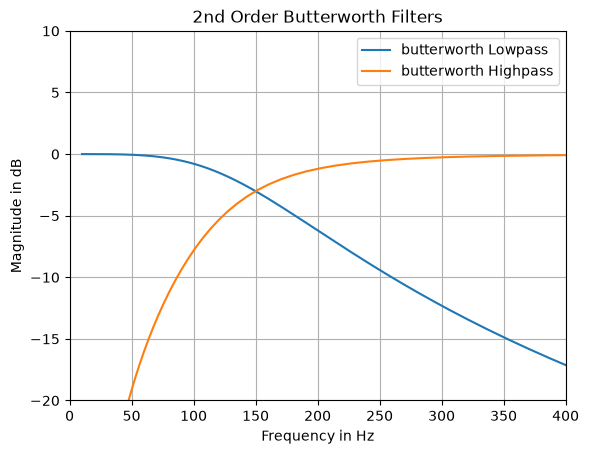

In [7]:
b_butt_lp, a_butt_lp = signal.butter(N, wc_norm, 'low', analog=True)
w_butt_lp, mag_butt_lp = signal.freqs(b_butt_lp, a_butt_lp)
mag_dB_butt_lp = 20*np.log10(abs(mag_butt_lp))

b_butt_hp, a_butt_hp = signal.butter(N, wc_norm, 'high', analog=True)
w_butt_hp, mag_butt_hp = signal.freqs(b_butt_hp, a_butt_hp)
mag_dB_butt_hp = 20*np.log10(abs(mag_butt_hp))


plt.plot(w_butt_lp*fs, mag_dB_butt_lp, label="butterworth Lowpass")
plt.plot(w_butt_hp*fs, mag_dB_butt_hp, label="butterworth Highpass")
plt.ylabel("Magnitude in dB")
plt.xlabel("Frequency in Hz")
plt.title("2nd Order Butterworth Filters")
plt.ylim([-20, 10])
plt.xlim([0, 400])
plt.grid()
plt.legend()
plt.show()

The plot shows the butterworth approximation for high- and lowpass filter.

## Sallen-Key Implementation
The Sallen-Key biquad can be used to implement second-order active filters with only one opamp.


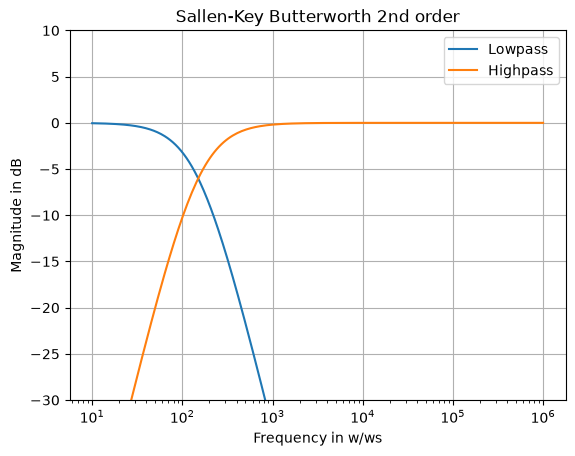

In [8]:
w0 = wc_norm
b_lp_sallen= np.array([0, 0, w0**2])
a_sallen = [1, w0/Q0, w0**2]

w_lp_sallen, mag_lp_sallen = signal.freqs(b_lp_sallen, a_sallen)
mag_lp_sallen_dB = 20*np.log10(abs(mag_lp_sallen))

b_hp_sallen = np.array([1, 0, 0])

w_hp_sallen, mag_hp_sallen = signal.freqs(b_hp_sallen, a_sallen)
mag_hp_sallen_dB = 20*np.log10(abs(mag_hp_sallen))

plt.semilogx(w_lp_sallen*fs, mag_lp_sallen_dB, label="Lowpass")
plt.semilogx(w_hp_sallen*fs, mag_hp_sallen_dB, label="Highpass")
plt.ylabel("Magnitude in dB")
plt.xlabel("Frequency in w/ws")
plt.title("Sallen-Key Butterworth 2nd order")
plt.ylim([-30,10])
#plt.xlim([0,400])
plt.grid()
plt.legend()
plt.show()

## Linkwitz-Riley crossover
The Linkwitz-Riley crossover uses two Sallen-Key filter implementation in parallel and sums their output signals.

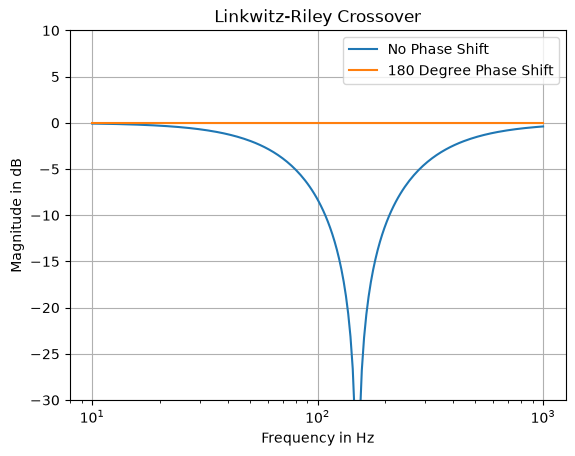

In [10]:
b_linkwitz= b_lp_sallen+b_hp_sallen
a_linkwitz = [1, w0/Q0, w0**2] 

b_linkwitz_shifted= b_lp_sallen+(-1)*b_hp_sallen

w_linkwitz, mag_linkwitz = signal.freqs(b_linkwitz, a_linkwitz)
mag_linkwitz_dB = 20*np.log10(abs(mag_linkwitz))

w_linkwitz_shifted, mag_linkwitz_shifted = signal.freqs(b_linkwitz_shifted, a_linkwitz)
mag_linkwitz_dB_shifted = 20*np.log10(abs(mag_linkwitz_shifted))

plt.semilogx(w_linkwitz*fs, mag_linkwitz_dB, label="No Phase Shift")
plt.semilogx(w_linkwitz_shifted*fs, mag_linkwitz_dB_shifted, label="180 Degree Phase Shift")
plt.ylabel("Magnitude in dB")
plt.xlabel("Frequency in Hz")
plt.title("Linkwitz-Riley Crossover")
plt.ylim([-30, 10])
plt.grid()
plt.legend()
plt.show()

## Full plot of all magnitude responses of a second order Linkwitz-Riley crossover
The Linkwitz-Riley crossover consists of two Sallen-Key filters, one low- and one highpass, and the sum of both. This
sum is the crossover. It its important, that the phase of one magnitude response is delayed by 180° or pi, so there is
no peak in the crossover magnitude. Overall consist the second order Linkwitz-Riley crossover of four OTAs/Opamps.

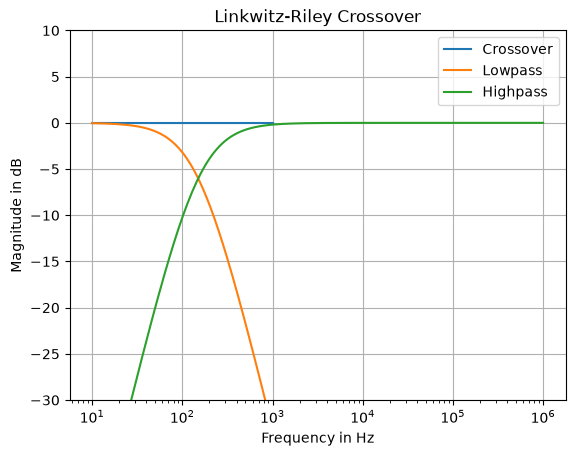

In [11]:
plt.plot(w_linkwitz_shifted*fs, mag_linkwitz_dB_shifted, label="Crossover")
plt.semilogx(w_lp_sallen*fs, mag_lp_sallen_dB, label="Lowpass")
plt.semilogx(w_hp_sallen*fs, mag_hp_sallen_dB, label="Highpass")
plt.ylabel("Magnitude in dB")
plt.xlabel("Frequency in Hz")
plt.title("Linkwitz-Riley Crossover")
plt.ylim([-30, 10])
plt.grid()
plt.legend()
plt.show()